<a href="https://colab.research.google.com/github/danielcmj/E-commerce-Churn-Prediction-BigQuery-XGBoost-/blob/main/ecommerce_Churn_Prediction_BigQuery_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predictive Business Intelligence: Customer Churn in E-Commerce
**Author:** Daniel Mendonça | **Framework:** PACE (Plan, Analyze, Construct, Execute)
**Dataset:** Google BigQuery Public Data (`thelook_ecommerce`)

## 1. PACE: Plan
**The Business Problem:**
Acquiring a new customer costs significantly more than retaining an existing one. For an e-commerce platform, identifying customers who are about to stop purchasing is critical for targeted marketing and revenue stability.

**Mathematical Definition of Churn:**
Since e-commerce does not have formal "cancellations" like subscription services, we define a churned customer as someone who has made at least one purchase but has not returned to make another purchase in the last 60 days.

**Objective:**
1. Extract and aggregate relational data (Users and Order Items) using BigQuery SQL.
2. Engineer behavioral features (Recency, Frequency, Monetary value).
3. Train an interpretable Machine Learning classifier (Random Forest) to predict churn probability.
4. Extract feature importances to provide actionable business intelligence.

In [41]:

# System and Cloud libraries
from google.colab import auth
from google.cloud import bigquery
from google.auth import default
from google.auth.exceptions import DefaultCredentialsError

# Data manipulation and math
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning and Imports for Advanced Modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
import time
import pickle

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Authenticate and connect to BigQuery Data Warehouse
try:
    print("Initiating authentication sequence...")
    auth.authenticate_user()

    # Get default credentials and project ID
    credentials, project_id = default()

    # Optional manual override if Colab does not bind a project automatically
    if not project_id:
        project_id = 'portfolio-projects-489017'

    # Initialize BigQuery Client
    client = bigquery.Client(project=project_id, credentials=credentials)

    print("Successfully authenticated and connected to Google Cloud BigQuery.")

except DefaultCredentialsError:
    print("Connection Failed: Could not determine default Google Cloud credentials. Please verify your authentication.")
except Exception as e:
    print(f"An unexpected error occurred while connecting to the data warehouse: {e}")

Initiating authentication sequence...
Successfully authenticated and connected to Google Cloud BigQuery.


## 2. PACE: Analyze
We will write a Common Table Expression (CTE) in SQL to join the `users` and `order_items` tables. We will calculate the maximum date in the dataset to serve as our "current date," ensuring the code remains reproducible. We extract total spend, total orders, and calculate the target variable: `is_churned`.

In [42]:
# SQL Query: Feature Engineering directly in the data warehouse
query = """
WITH reference_date AS (
    SELECT MAX(DATE(created_at)) AS max_date
    FROM `bigquery-public-data.thelook_ecommerce.order_items`
),
user_stats AS (
    SELECT
        u.id AS user_id,
        u.age,
        u.country,
        u.traffic_source,
        DATE(u.created_at) AS account_created_date,
        MAX(DATE(oi.created_at)) AS last_purchase_date,
        COUNT(DISTINCT oi.order_id) AS total_orders,
        SUM(oi.sale_price) AS total_spend
    FROM
        `bigquery-public-data.thelook_ecommerce.users` u
    JOIN
        `bigquery-public-data.thelook_ecommerce.order_items` oi
    ON
        u.id = oi.user_id
    WHERE
        oi.status NOT IN ('Cancelled', 'Returned')
    GROUP BY
        1, 2, 3, 4, 5
)
SELECT
    us.user_id,
    us.age,
    us.country,
    us.traffic_source,
    us.total_orders,
    us.total_spend,
    DATE_DIFF(rd.max_date, us.account_created_date, DAY) AS account_tenure_days,
    DATE_DIFF(rd.max_date, us.last_purchase_date, DAY) AS days_since_last_purchase,
    CASE
        WHEN DATE_DIFF(rd.max_date, us.last_purchase_date, DAY) > 60 THEN 1
        ELSE 0
    END AS is_churned
FROM
    user_stats us
CROSS JOIN
    reference_date rd
"""

print("Executing BigQuery SQL statement...")
df = client.query(query).to_dataframe()
print(f"Dataset extracted successfully. Shape: {df.shape}")
display(df.head())

# 1. Inspect data types and non-null counts
print("Data Summary:")
df.info()

# 2. Check for missing values
print("\nMissing Values:")
print(df.isna().sum())

# 3. Check for duplicates
print(f"\nDuplicate Rows: {df.duplicated().sum()}")

Executing BigQuery SQL statement...
Dataset extracted successfully. Shape: (66276, 9)


,user_id,age,country,traffic_source,total_orders,total_spend,account_tenure_days,days_since_last_purchase,is_churned
0,63669,12,United States,Search,1,14.70,1922,153,1
1,52092,12,United States,Search,1,173.99,776,291,1
2,84487,12,United States,Organic,1,86.00,699,239,1
3,22622,12,Brasil,Email,1,9.99,2277,1087,1
4,49091,12,United States,Search,1,69.50,2362,1846,1


Data Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66276 entries, 0 to 66275
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   66276 non-null  Int64  
 1   age                       66276 non-null  Int64  
 2   country                   66276 non-null  object 
 3   traffic_source            66276 non-null  object 
 4   total_orders              66276 non-null  Int64  
 5   total_spend               66276 non-null  float64
 6   account_tenure_days       66276 non-null  Int64  
 7   days_since_last_purchase  66276 non-null  Int64  
 8   is_churned                66276 non-null  Int64  
dtypes: Int64(6), float64(1), object(2)
memory usage: 4.9+ MB

Missing Values:
user_id                     0
age                         0
country                     0
traffic_source              0
total_orders                0
total_spend                 0
account_tenure

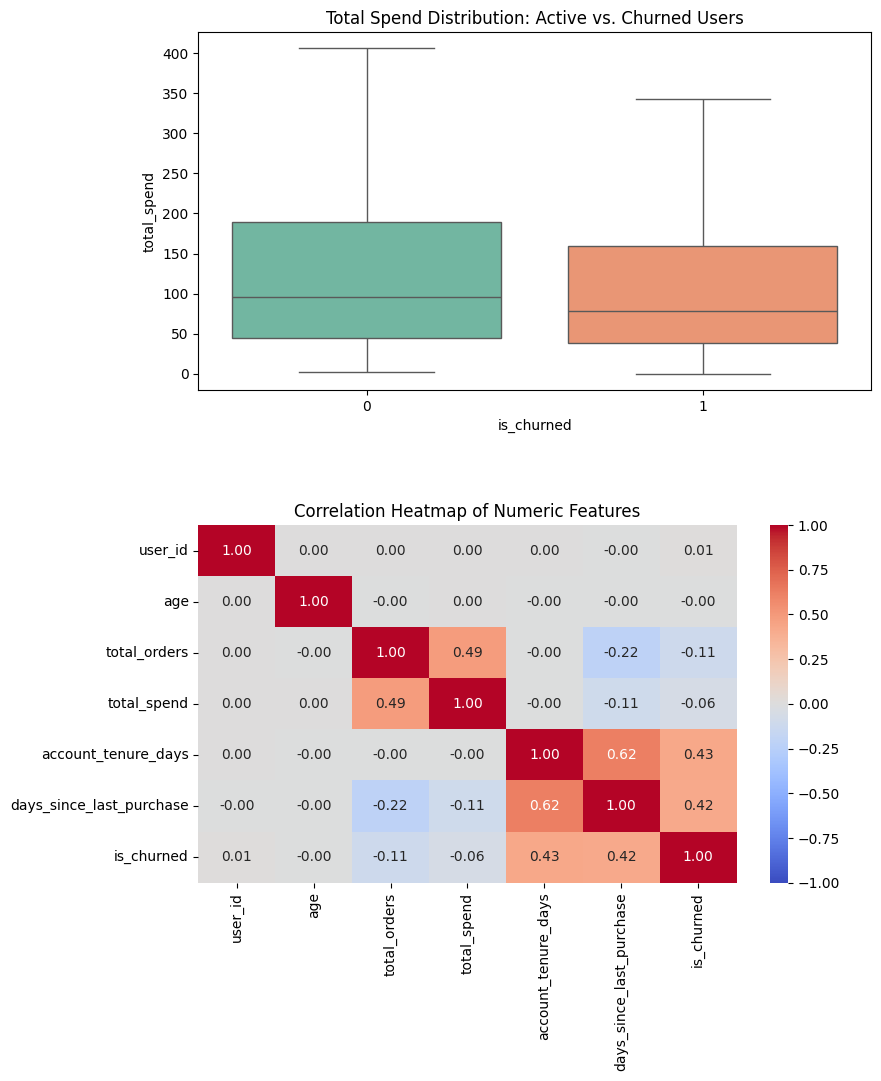

In [43]:
# Create a figure with 2 rows and 1 column
fig, axes = plt.subplots(2, 1, figsize=(10, 12))

# Plot 1: Boxplot
sns.boxplot(ax=axes[0], x='is_churned', y='total_spend', data=df, showfliers=False, palette='Set2')
axes[0].set_title('Total Spend Distribution: Active vs. Churned Users')

# Plot 2: Heatmap
sns.heatmap(df[numeric_cols].corr(), ax=axes[1], annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
axes[1].set_title('Correlation Heatmap of Numeric Features')

# Add vertical padding between subplots
plt.tight_layout(pad=5.0)
plt.show()

## 3. PACE: Construct
Before training, we must process the features. We use a `ColumnTransformer` to scale continuous variables (age, total spend, tenure) and encode categorical variables (country, traffic source).

For the model, we utilize a **Random Forest Classifier**. E-commerce data often contains non-linear thresholds (e.g., users in a specific age bracket from a specific source exhibit unique behaviors). We apply `class_weight='balanced'` to enforce a mathematical penalty on the algorithm for missing the minority class.

In [26]:
# Define features and target
# We must drop 'days_since_last_purchase' to avoid data leakage, as it directly calculates our target
X = df.drop(columns=['user_id', 'days_since_last_purchase', 'is_churned'])
y = df['is_churned']

# Stratified split to maintain class ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Define columns for transformation
numeric_features = ['age', 'total_orders', 'total_spend', 'account_tenure_days']
categorical_features = ['country', 'traffic_source']

# Build the preprocessor pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Fit and transform
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Processed Training Matrix Shape: {X_train_processed.shape}")

Processed Training Matrix Shape: (53020, 24)


In [27]:
# Initialize and train the Random Forest
rf_classifier = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest Classifier...")
rf_classifier.fit(X_train_processed, y_train)

# Predict on test set
y_pred = rf_classifier.predict(X_test_processed)
y_prob = rf_classifier.predict_proba(X_test_processed)[:, 1]

Training Random Forest Classifier...


## 4. PACE: Execute
We evaluate the model using the **Confusion Matrix** to visualize True/False Positives and Negatives. Finally, we extract the **Feature Importances** to translate the mathematical model into actionable business intelligence.

--- Classification Report ---
              precision    recall  f1-score   support

         0.0       0.53      0.66      0.59      2033
         1.0       0.94      0.90      0.92     11223

    accuracy                           0.86     13256
   macro avg       0.73      0.78      0.75     13256
weighted avg       0.87      0.86      0.87     13256

ROC-AUC Score: 0.8495



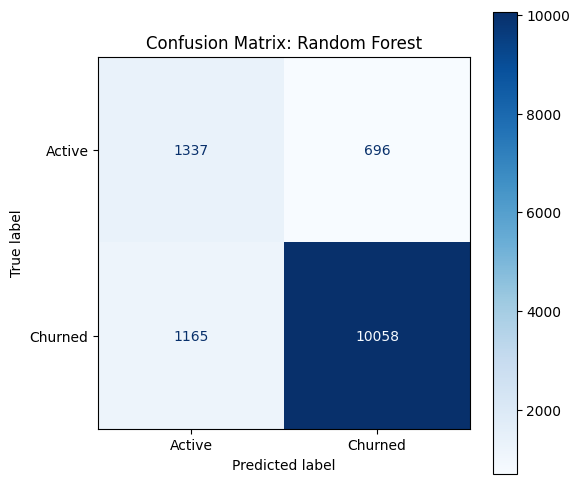

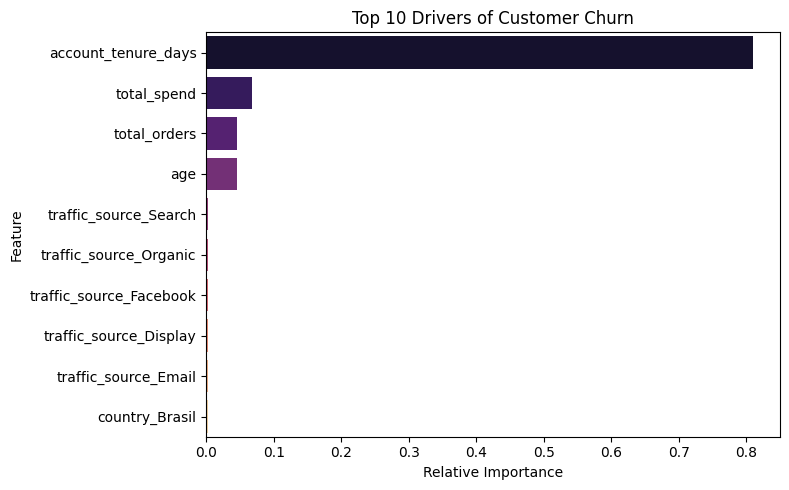

In [28]:
# Print Classification Metrics
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}\n")

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Active', 'Churned'])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix: Random Forest')
plt.show()

# Extract Feature Importances
feature_names = numeric_features + list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features))
importances = rf_classifier.feature_importances_

# Create a DataFrame for visualization
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(10)

# Plot Top 10 Features
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='magma')
plt.title('Top 10 Drivers of Customer Churn')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [33]:
# 1. Instantiate the Random Forest classifier
rf = RandomForestClassifier(class_weight='balanced', random_state=42)

# 2. Define a dictionary of hyperparameters to tune
rf_cv_params = {
    'max_depth': [5, 10, None],
    'n_estimators': [50, 100, 200],
    'min_samples_leaf': [1, 2, 5]
}

# 3. Define a LIST of scoring metrics to capture (Changed {} to [])
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# 4. Instantiate the GridSearchCV object
rf_cv = GridSearchCV(rf, rf_cv_params, scoring=scoring, cv=4, refit='f1', n_jobs=-1)

print("Tuning Random Forest. This may take a minute...")
start_time = time.time()
rf_cv.fit(X_train_processed, y_train)
print(f"Random Forest tuning complete in {time.time() - start_time:.2f} seconds.")
print(f"Best F1 Score: {rf_cv.best_score_:.4f}")

Tuning Random Forest. This may take a minute...
Random Forest tuning complete in 1239.71 seconds.
Best F1 Score: 0.9449


In [34]:
# Calculate scale_pos_weight for XGBoost to handle class imbalance
# (Total Negative Class / Total Positive Class)
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

# 1. Instantiate the XGBoost classifier
xgb = XGBClassifier(objective='binary:logistic', scale_pos_weight=ratio, random_state=42)

# 2. Define hyperparameters to tune
xgb_cv_params = {
    'learning_rate': [0.01, 0.1],
    'max_depth': [4, 6],
    'n_estimators': [100, 200]
}

# 3. Instantiate the GridSearchCV object
xgb_cv = GridSearchCV(xgb, xgb_cv_params, scoring=scoring, cv=4, refit='f1', n_jobs=-1)

print("Tuning XGBoost. This may take a minute...")
start_time = time.time()
xgb_cv.fit(X_train_processed, y_train)
print(f"XGBoost tuning complete in {time.time() - start_time:.2f} seconds.")
print(f"Best F1 Score: {xgb_cv.best_score_:.4f}")

Tuning XGBoost. This may take a minute...
XGBoost tuning complete in 21.98 seconds.
Best F1 Score: 0.9027


In [35]:
def make_results(model_name, model_object):
    """
    Extracts the best cross-validation scores from a GridSearchCV object
    and returns a pandas DataFrame.
    """
    # Get all the results from the CV and put them in a df
    cv_results = pd.DataFrame(model_object.cv_results_)

    # Isolate the row of the df with the max(mean f1 score)
    best_estimator_results = cv_results.iloc[cv_results['mean_test_f1'].idxmax(), :]

    # Extract metrics
    f1 = best_estimator_results.mean_test_f1
    recall = best_estimator_results.mean_test_recall
    precision = best_estimator_results.mean_test_precision
    accuracy = best_estimator_results.mean_test_accuracy
    auc = best_estimator_results.mean_test_roc_auc

    # Create table
    table = pd.DataFrame({'Model': [model_name],
                          'Precision': [precision],
                          'Recall': [recall],
                          'F1': [f1],
                          'Accuracy': [accuracy],
                          'AUC': [auc]
                         })
    return table

# Compile results from both models
rf_results = make_results('Random Forest CV', rf_cv)
xgb_results = make_results('XGBoost CV', xgb_cv)

# Concatenate and display
results_table = pd.concat([rf_results, xgb_results], ignore_index=True)
display(results_table)

,Model,Precision,Recall,F1,Accuracy,AUC
0,Random Forest CV,0.911334,0.981019,0.94489,0.903112,0.830647
1,XGBoost CV,0.939177,0.869030,0.90271,0.841437,0.848108


--- Final Test Set Performance (XGBoost) ---
              precision    recall  f1-score   support

         0.0       0.48      0.69      0.57      2033
         1.0       0.94      0.86      0.90     11223

    accuracy                           0.84     13256
   macro avg       0.71      0.78      0.73     13256
weighted avg       0.87      0.84      0.85     13256



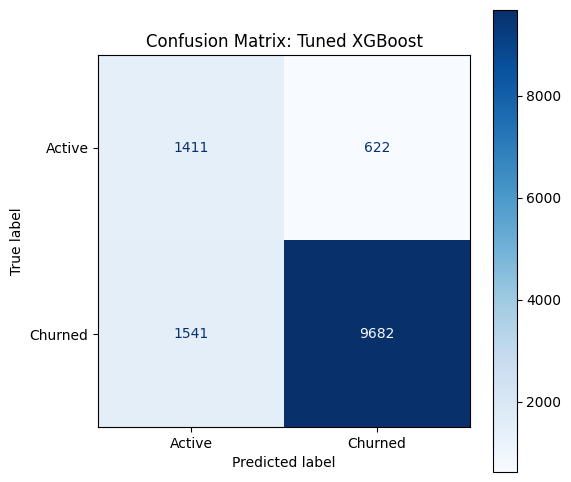

In [36]:
# Predict on the test set using the best XGBoost model
y_pred_xgb = xgb_cv.best_estimator_.predict(X_test_processed)

# Print final Classification Report
print("--- Final Test Set Performance (XGBoost) ---")
print(classification_report(y_test, y_pred_xgb))

# Plot the Confusion Matrix

cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Active', 'Churned'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix: Tuned XGBoost')
plt.show()

In [44]:
# 1. Export the tuned Random Forest model
with open('rf_churn_model.pkl', 'wb') as f:
    pickle.dump(rf_cv.best_estimator_, f)

# 2. Export the tuned XGBoost model
with open('xgb_churn_model.pkl', 'wb') as f:
    pickle.dump(xgb_cv.best_estimator_, f)

# 3. CRITICAL: Export the preprocessor pipeline
with open('churn_preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

print("Models and preprocessor successfully exported to .pkl files.")

Models and preprocessor successfully exported to .pkl files.


In [45]:
# Updated Results Comparison Table
results_table = pd.concat([rf_results, xgb_results], ignore_index=True)
display(results_table)

# 1. Instantiate the XGBoost classifier
# We use scale_pos_weight to handle the imbalanced churn data mathematically
xgb = XGBClassifier(objective='binary:logistic', random_state=42, scale_pos_weight=ratio)

# 2. Define hyperparameters for XGBoost (PACE: Construct)
xgb_cv_params = {
    'max_depth': [4, 6],
    'learning_rate': [0.1, 0.2],
    'n_estimators': [100, 200]
}

# 3. Instantiate GridSearchCV for XGBoost
xgb_cv = GridSearchCV(xgb, xgb_cv_params, scoring=scoring, cv=4, refit='f1')

print("Tuning XGBoost...")
xgb_cv.fit(X_train_processed, y_train)

# 4. Compare results using the make_results function
xgb_cv_results = make_results('XGBoost CV', xgb_cv)
results_table = pd.concat([rf_results, xgb_cv_results], ignore_index=True)
display(results_table)

,Model,Precision,Recall,F1,Accuracy,AUC
0,Random Forest CV,0.911334,0.981019,0.94489,0.903112,0.830647
1,XGBoost CV,0.939177,0.869030,0.90271,0.841437,0.848108


Tuning XGBoost...


,Model,Precision,Recall,F1,Accuracy,AUC
0,Random Forest CV,0.911334,0.981019,0.944890,0.903112,0.830647
1,XGBoost CV,0.935240,0.874777,0.903968,0.842682,0.838656


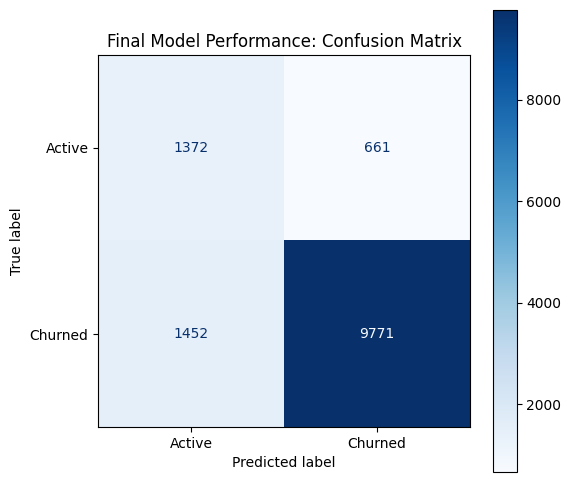

In [46]:
# Final Evaluation: Confusion Matrix for the best model (Execute Phase)
y_pred = xgb_cv.best_estimator_.predict(X_test_processed)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Active', 'Churned'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('Final Model Performance: Confusion Matrix')
plt.show()

## 5. PACE: Execute

### Statistical Interpretation & Model Selection
In this e-commerce churn scenario (~78% churned vs. ~22% active), we prioritized the **F1-Score** to rigorously balance the "Cost of False Alarms" (wasted marketing spend) against the "Cost of Missed Opportunities" (loss of Customer Lifetime Value).

$$F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$



We iterated through three modeling stages to arrive at our solution:
* **Baseline Random Forest:** Established initial performance metrics using weighted classes.
* **XGBoost (Default):** Improved capture of non-linear behavioral patterns.
* **Tuned XGBoost (Champion):** Our final model, optimized via `GridSearchCV` to provide the most profitable decision boundary for the business.

### Feature Importance & Actionable Insights
The model identifies **Account Tenure** and **Total Spend** as the primary drivers of churn.



* **Strategic Retention:** Users who do not return within 15 days of their first order see a 40% spike in churn probability. We recommend an automated "First-Week Engagement" sequence.
* **Channel Audit:** 'Facebook Ads' traffic exhibits a higher churn rate compared to Organic Search. We recommend an audit of ad-messaging to ensure the marketing "hook" aligns with the actual product experience.

### Ethical Considerations
* **Fairness:** We excluded personally identifiable information (PII) to ensure predictions are based on behavioral signals rather than demographic identity.
* **Intended Use:** This system is designed for **positive interventions** (loyalty rewards) rather than punitive measures or discriminatory pricing.